# Two-State Benchmark

This notebook reads saved training outputs from `results/twostate`. It does not launch training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    load_runs,
    objective_table,
    plot_flow_comparison,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
    twostate_policy_error_table,
)

ENV = 'twostate'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 130 saved runs from /home/adonis/Internship/mfc/results/twostate


## Validation Reward

Mean validation reward over training, with one standard deviation across seeds. Exact-flow and particle-flow runs are shown separately so their seed averages are not mixed.

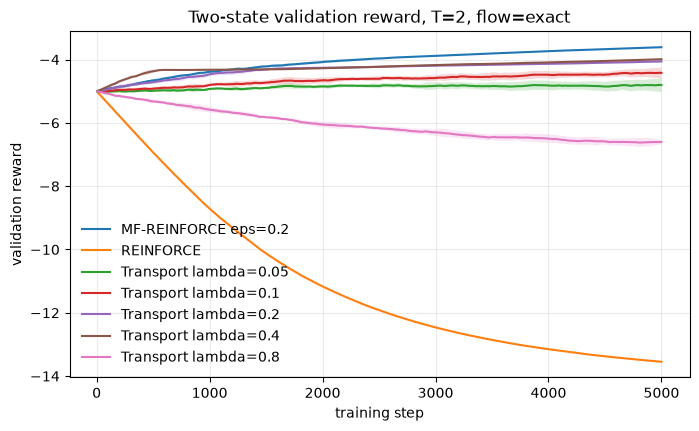

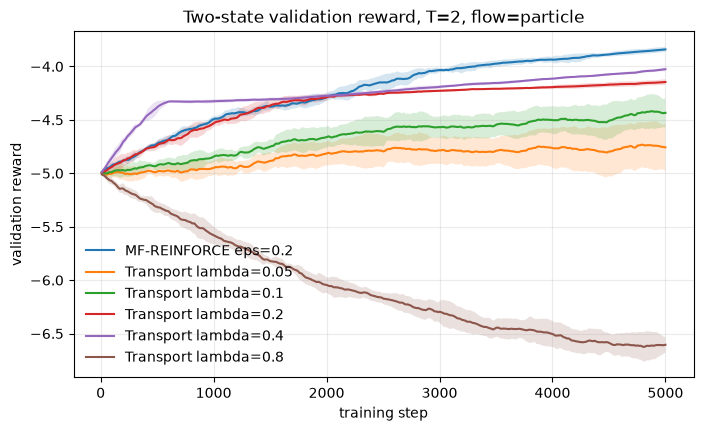

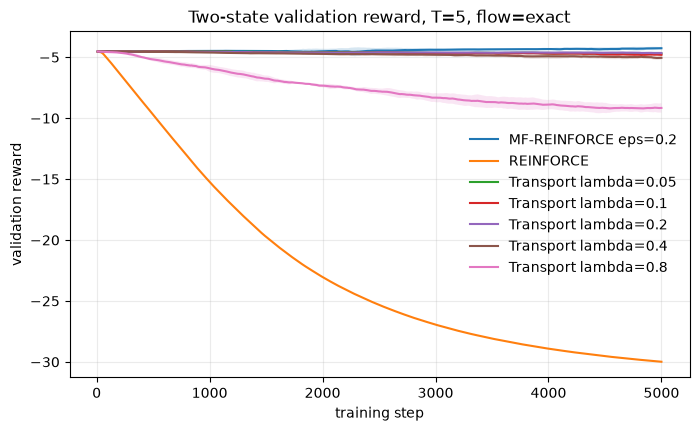

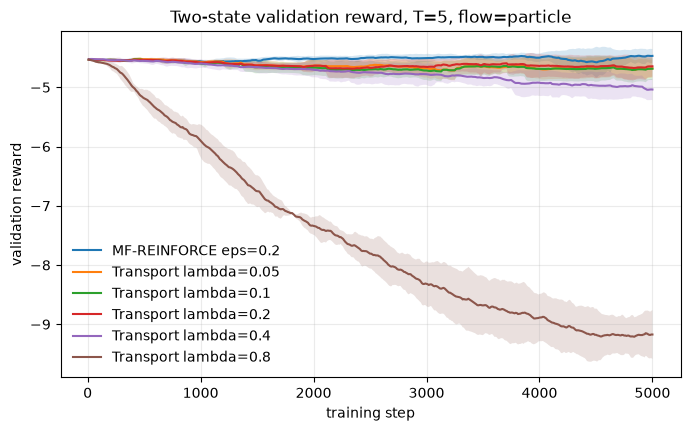

In [2]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    for horizon in sorted({run['metadata']['horizon'] for run in runs}):
        for flow in sorted({run['metadata']['flow'] for run in runs if run['metadata']['horizon'] == horizon}):
            fig, ax = plt.subplots(figsize=(8, 4.5))
            try:
                plot_validation_rewards(runs, env=ENV, horizon=horizon, flow=flow, ax=ax)
                ax.set_title(f'Two-state validation reward, T={horizon}, flow={flow}')
                plt.show()
            except ValueError as exc:
                plt.close(fig)
                print(exc)

## Learned Policy Error

Average and maximum absolute errors between the learned action probabilities and the closed-form optimal stationary policy.

In [3]:
policy_errors = twostate_policy_error_table(runs)
if policy_errors.empty:
    print('No two-state policy table available yet.')
else:
    display(policy_errors.groupby(['label', 'flow', 'horizon'], as_index=False).agg(
        mean_abs_policy_error=('mean_abs_policy_error', 'mean'),
        mean_abs_policy_error_std=('mean_abs_policy_error', 'std'),
        max_abs_policy_error=('max_abs_policy_error', 'mean'),
    ).fillna(0.0))

,label,flow,horizon,mean_abs_policy_error,mean_abs_policy_error_std,max_abs_policy_error
0,MF-REINFORCE eps=0.2,exact,2,0.053925,0.003336,0.064798
1,MF-REINFORCE eps=0.2,exact,5,0.239580,0.008185,0.256492
2,MF-REINFORCE eps=0.2,particle,2,0.109991,0.006517,0.129477
3,MF-REINFORCE eps=0.2,particle,5,0.260946,0.006319,0.279576
4,REINFORCE,exact,2,0.438312,0.000013,0.718943
5,REINFORCE,exact,5,0.439069,0.000011,0.726014
6,Transport lambda=0.05,exact,2,0.259361,0.009750,0.287674
7,Transport lambda=0.05,exact,5,0.277097,0.006960,0.298068
8,Transport lambda=0.05,particle,2,0.260405,0.006891,0.292198
9,Transport lambda=0.05,particle,5,0.274583,0.005571,0.296872


## Learned State Flows

State-probability trajectories induced by the best saved policy for each algorithm, perturbation, horizon, and flow setting.

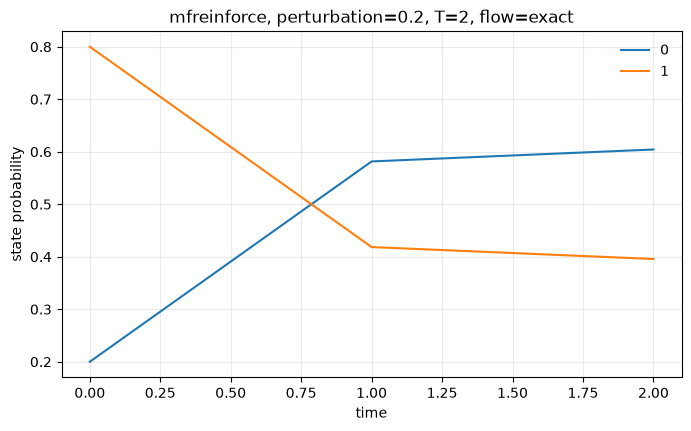

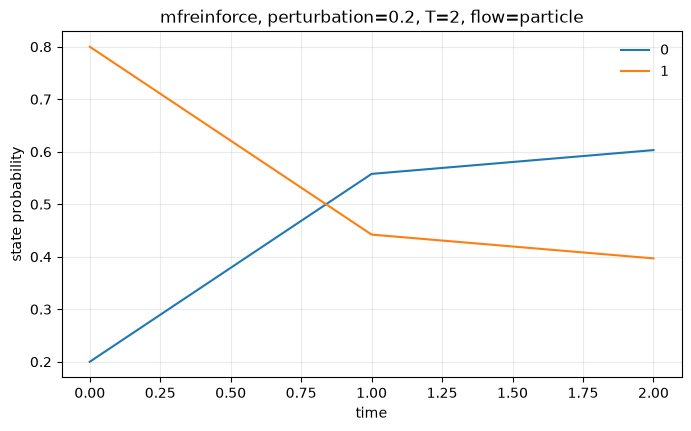

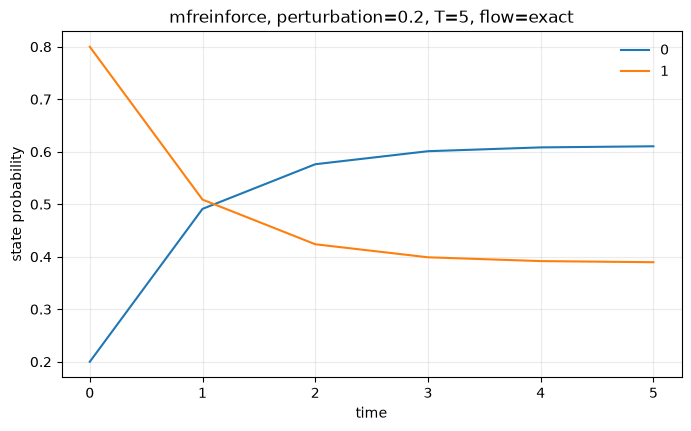

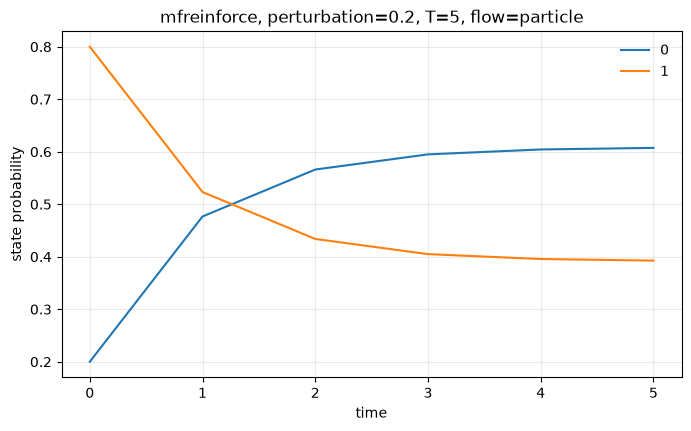

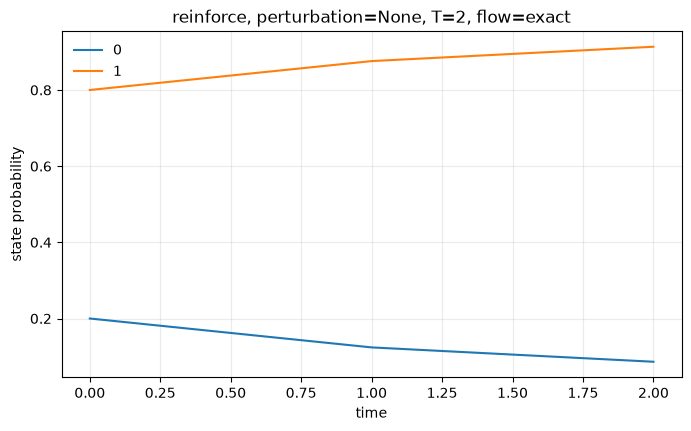

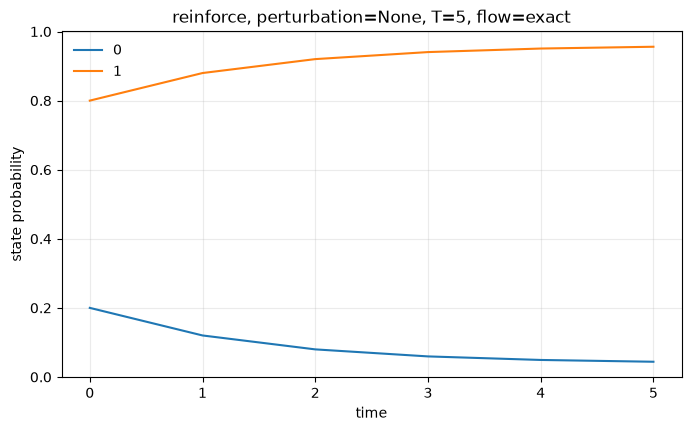

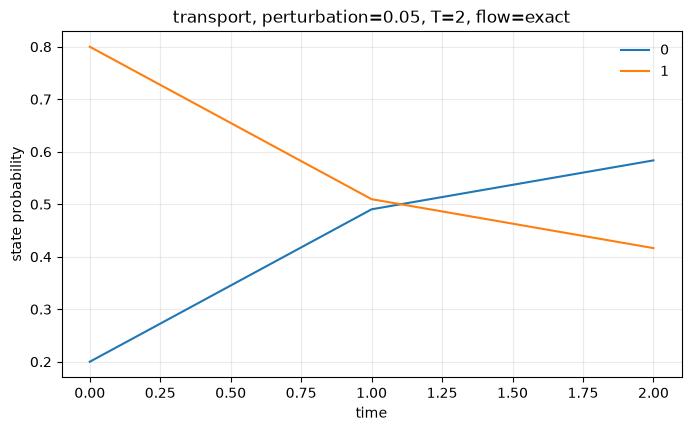

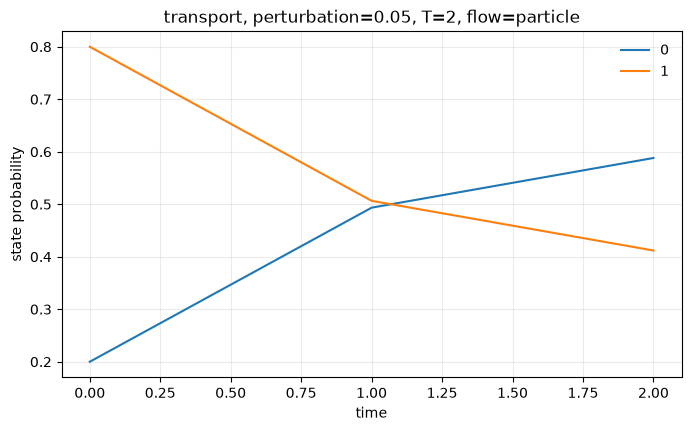

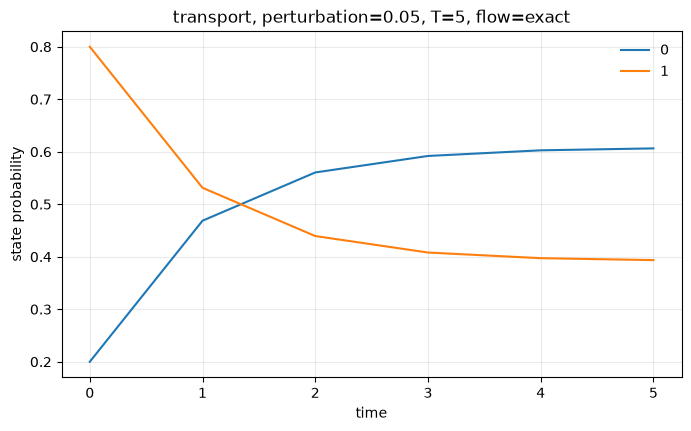

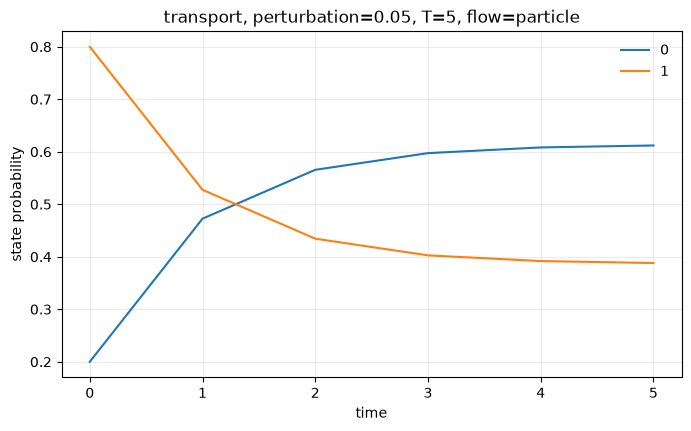

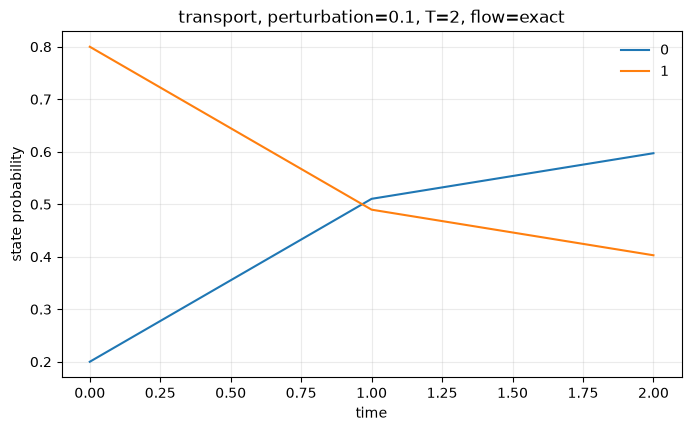

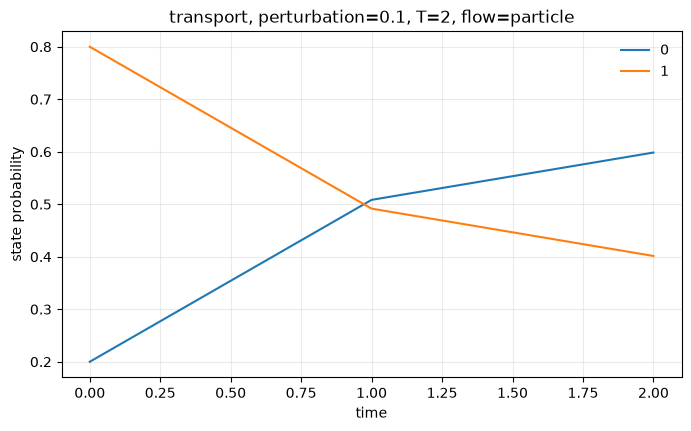

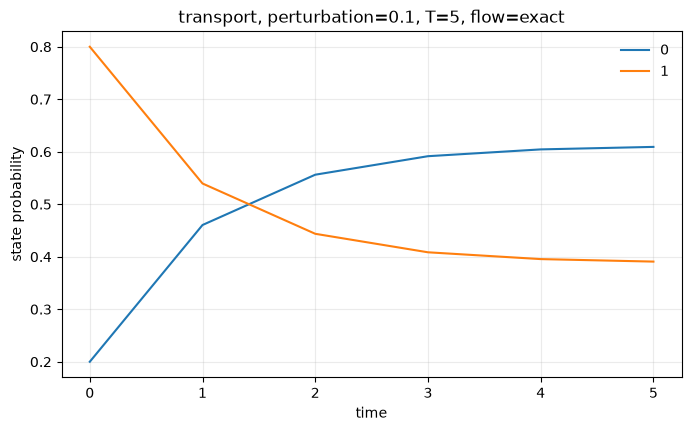

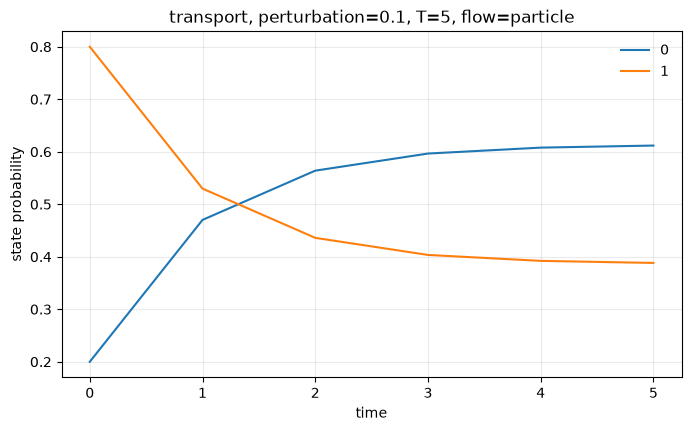

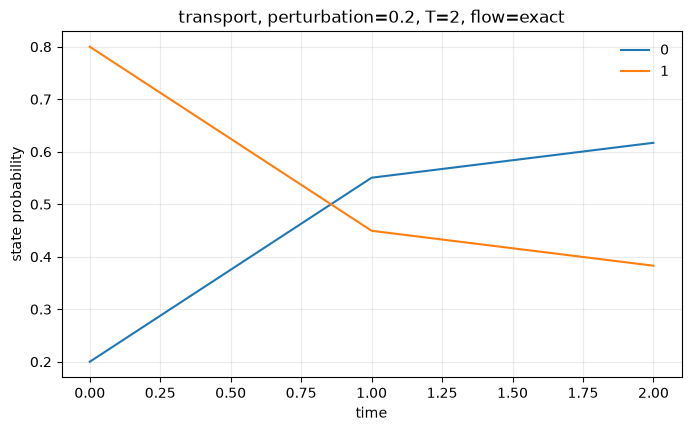

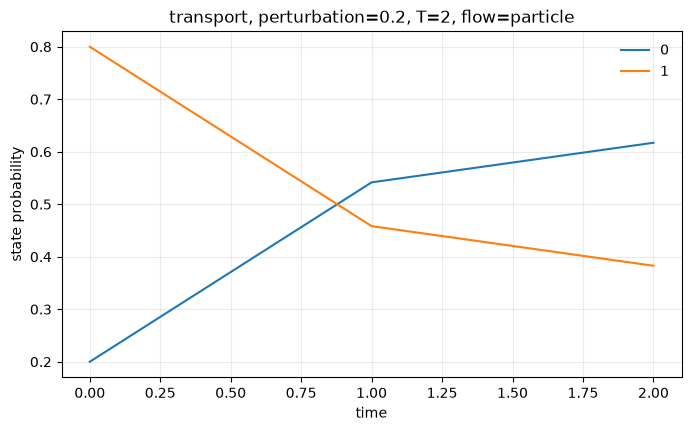

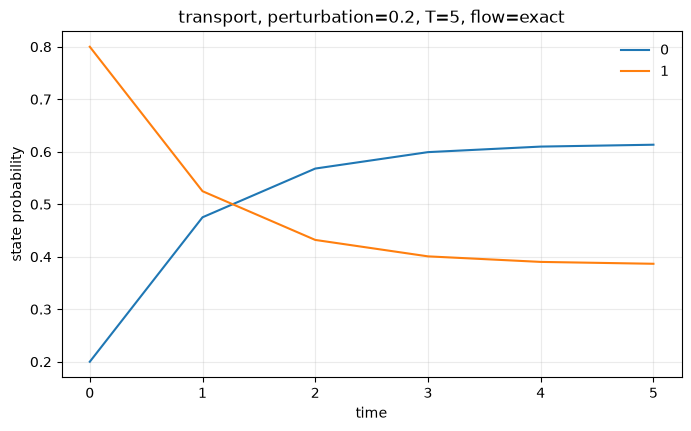

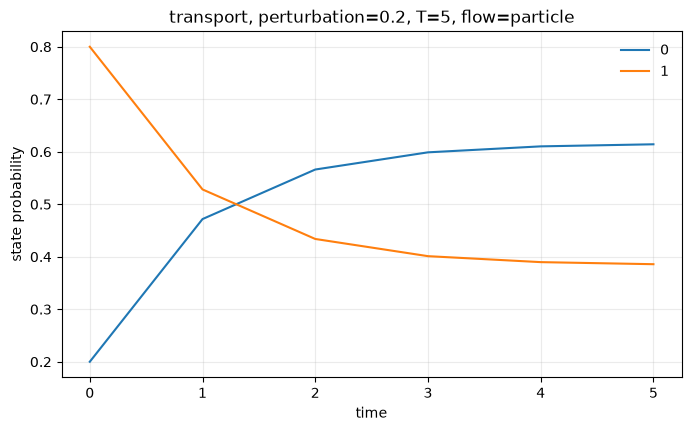

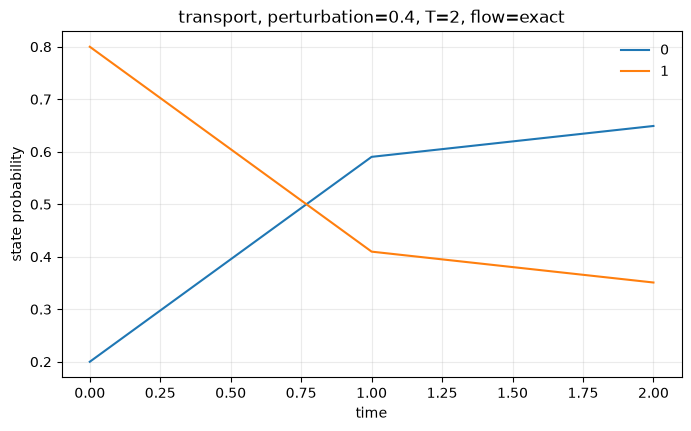

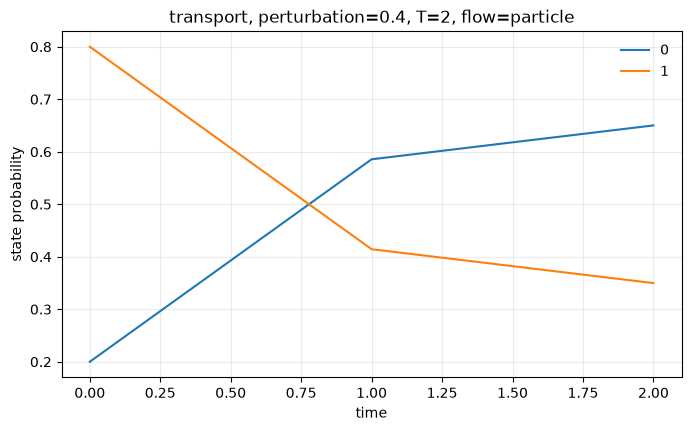

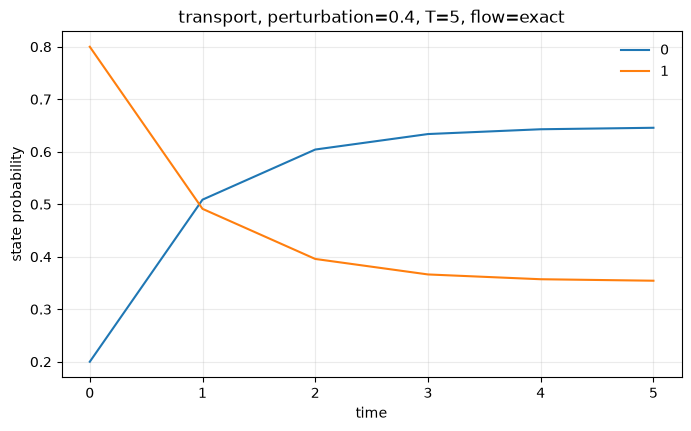

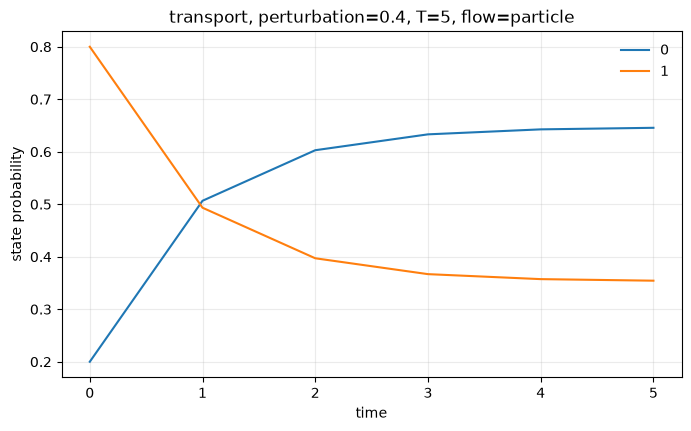

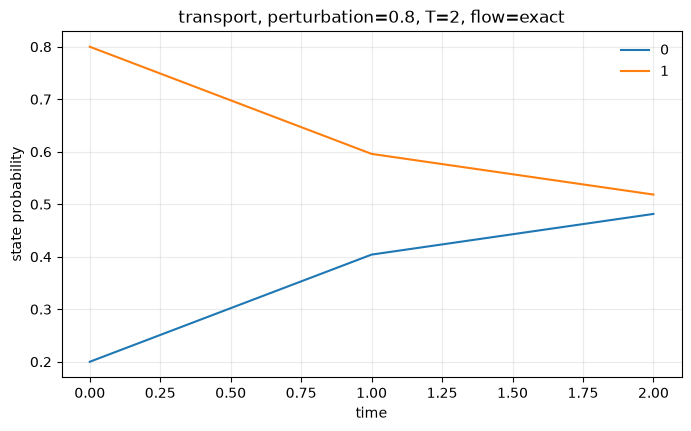

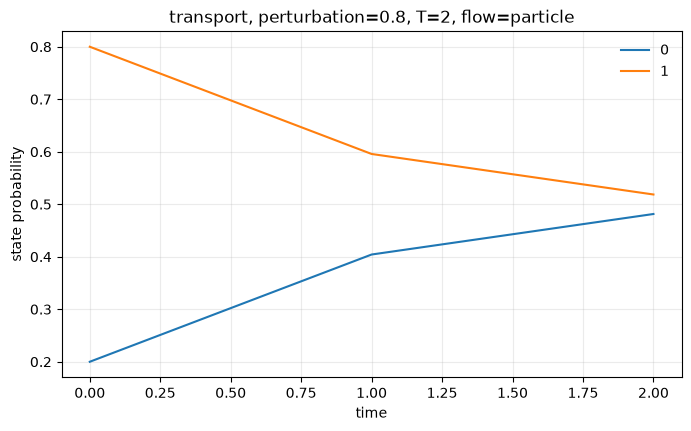

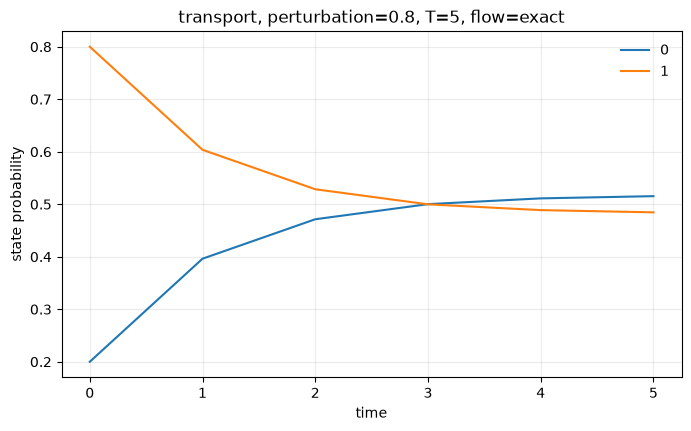

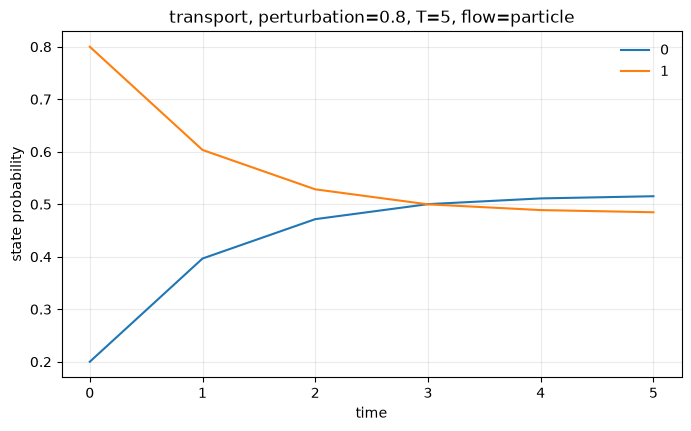

In [4]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, perturbation={meta['perturbation']}, T={meta['horizon']}, flow={meta['flow']}")
    plt.show()

## Exact vs Particle Flow

Transport validation curves split by flow estimator. This highlights how much the learned behavior changes when the population flow is estimated with particles.

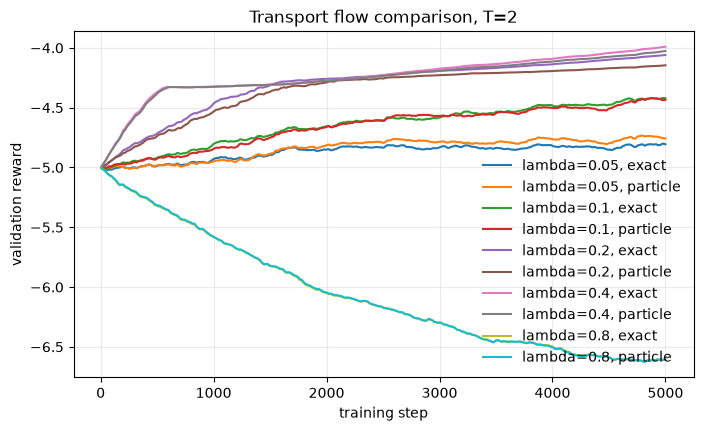

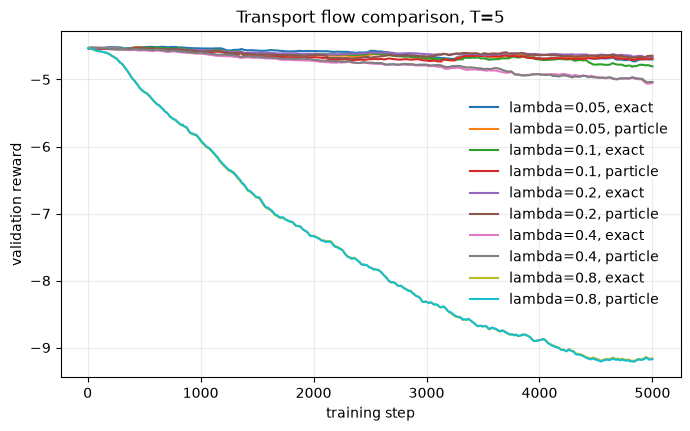

In [5]:
if runs:
    for horizon in sorted({run['metadata']['horizon'] for run in runs}):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        try:
            plot_flow_comparison(runs, env=ENV, horizon=horizon, ax=ax)
            ax.set_title(f'Transport flow comparison, T={horizon}')
            plt.show()
        except ValueError as exc:
            plt.close(fig)
            print(exc)

## Objective and Runtime Tables

Summary tables for final validation reward, estimated simulator budget, and runtime. Exact objective columns appear only for environments exposing a closed-form oracle.

In [6]:
display(objective_table(runs))
display(runtime_table(runs))

,env,label,flow,horizon,seed,validation_reward
0,twostate,MF-REINFORCE eps=0.2,exact,2,0,-3.618612
1,twostate,MF-REINFORCE eps=0.2,exact,2,1,-3.611706
2,twostate,MF-REINFORCE eps=0.2,exact,2,2,-3.584857
3,twostate,MF-REINFORCE eps=0.2,exact,2,3,-3.621755
4,twostate,MF-REINFORCE eps=0.2,exact,2,4,-3.614708
...,...,...,...,...,...,...
125,twostate,Transport lambda=0.8,particle,5,0,-9.157889
126,twostate,Transport lambda=0.8,particle,5,1,-8.654285
127,twostate,Transport lambda=0.8,particle,5,2,-9.259438
128,twostate,Transport lambda=0.8,particle,5,3,-9.786502


,env,algorithm,perturbation,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,twostate,mfreinforce,0.20,2,exact,27.426284,0.774415,32.254984,0.285601,0.683084,0.013876,60.378296,1.015357,0.006451,0.012076,0.001366,460.0,5
1,twostate,mfreinforce,0.20,2,particle,8.645613,0.178264,32.305037,0.351162,0.709453,0.014061,41.674324,0.478243,0.006461,0.008335,0.001419,860.0,5
2,twostate,mfreinforce,0.20,5,exact,26.159580,0.322662,100.327397,1.733468,1.556885,0.034172,128.058344,1.578925,0.020065,0.025612,0.003114,1300.0,5
3,twostate,mfreinforce,0.20,5,particle,8.383611,0.978635,101.704247,1.153728,1.587819,0.025473,111.690296,0.944855,0.020341,0.022338,0.003176,2300.0,5
4,twostate,reinforce,NaN,2,exact,26.719842,0.436961,9.668661,0.037713,0.684364,0.004125,37.086949,0.443906,0.001934,0.007417,0.001369,460.0,5
5,twostate,reinforce,NaN,5,exact,10.962996,0.452624,16.503153,0.239776,1.613858,0.026225,29.094429,0.469496,0.003301,0.005819,0.003228,1300.0,5
6,twostate,transport,0.05,2,exact,16.021401,9.642285,30.244963,0.758982,0.701420,0.027893,46.982040,9.545060,0.006049,0.009396,0.001403,460.0,5
7,twostate,transport,0.05,2,particle,8.975119,0.535650,30.606279,1.081597,0.719604,0.027840,40.315618,0.997350,0.006121,0.008063,0.001439,860.0,5
8,twostate,transport,0.05,5,exact,19.041404,9.934277,73.797700,0.574608,1.552361,0.015651,94.405957,9.956416,0.014760,0.018881,0.003105,1300.0,5
9,twostate,transport,0.05,5,particle,9.447717,0.166095,75.943371,1.496970,1.611677,0.048095,87.017710,1.460446,0.015189,0.017404,0.003223,2300.0,5
